In [ ]:
%load_ext eradiate

In [ ]:
import attrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [ ]:
import eradiate

eradiate.set_mode("mono_polarized")
integrator = "eovolpath"

In [ ]:
from eradiate.units import unit_registry as ureg

## I. Coordinates definition

 - The ZGrid class is removed in favor of two 3D coordinate grid classes handling plane parallel and spherical shell geometries
 - The `grid` module defines these class at the top level of the eradiate package (i.e. `eradiate.grid`). The ZGrid class used to be defined within the radprops module
 - Grids provide a mappring from geometric coordinates to the internal grid data storage facilities in Eradiate, always indexed on unsigned 3D array positions X, Y and Z. 
 - `eradiate.grid` centralizes the logic for coordinate mapping, a useful property for future developments.

In [ ]:
from eradiate.grid import GridCoords, PlaneParallelGridCoords, SphericalShellGridCoords

In [ ]:
z_grid = GridCoords.make_default()
z_grid

In [ ]:
grid_test = z_grid.resampled_to_cell_size(0.5 * ureg.hm, 0.5 * ureg.hm)
grid_test = grid_test.cropped(2 * ureg.hm, 3 * ureg.hm)
grid_test

In [ ]:
grid_3d = PlaneParallelGridCoords(
    levels=np.linspace(0, 100, 101) * ureg.m,
    edges_x=grid_test.edges_x,
    edges_y=grid_test.edges_y,
)

In [ ]:
grid_3d

The PlaneParallelGridCoords defines a mapping from cartesian coordinates space of the scene to 3D memory array cells according to its discretization.

In [ ]:
SphericalShellGridCoords(
    levels=np.linspace(0, 100, 101) * ureg.meter,
    azimuths=np.linspace(175, 185, 11) * ureg.degree,
    colatitudes=np.linspace(85, 95, 11) * ureg.degree,
)

In [ ]:
grid_1d = grid_3d.single_column()

## II. Geometry

The geometry interfaces accepts 3D grids. The geometry defines the medium shape, its extent, and the bounding box in which its component are evaluated.

In [ ]:
from eradiate.scenes.geometry import PlaneParallelGeometry

geometry_3d = PlaneParallelGeometry(grid=grid_3d, toa_altitude=grid_3d.levels[-1])
geometry_3d

In [ ]:
geometry_3d.width

The geometry is thus much larger than the grid, defining the coordinates on which the datasets are defined.

1D grids are still supported:

In [ ]:
grid_1d = PlaneParallelGridCoords(
    levels=np.linspace(0, 100, 101) * ureg.m,
    edges_x=[-5e5, 5e5] * ureg.km,
    edges_y=[-5e5, 5e5] * ureg.km,
)
geometry_1d = PlaneParallelGeometry(grid=grid_1d, toa_altitude=grid_1d.levels[-1])

## II. Emulating 1D atmospheres

In [ ]:
from eradiate.scenes.atmosphere import MolecularAtmosphere, ParticleLayer

atmosphere_1d = MolecularAtmosphere(geometry=geometry_1d)
atmosphere_3d = MolecularAtmosphere(geometry=geometry_3d)

In [ ]:
from eradiate.experiments import AtmosphereExperiment

exp_1d = AtmosphereExperiment(atmosphere=atmosphere_1d)
exp_3d = AtmosphereExperiment(atmosphere=atmosphere_3d)

res_1d = eradiate.run(exp_1d, spp=100000)
res_3d = eradiate.run(exp_3d, spp=100000)

assert np.allclose(res_1d.radiance.item(), res_3d.radiance.item(), rtol=1e-2)

## III. 3D Particle Layers

Spatial variations are defined mostly using a column major process. Five spatial variation implementations are provided:
 - Optical thickness $\tau_{ref}$ variation for each column
 - Spatially varying Z extents along the X or Y axes
 - Horizontal distributions evaluated along the X or Y axes
 - Spatially varying Z-columns distribution parameters along the X or Y axes
 - Distribution compositions

### 1. $\tau_{ref}$ variations w.r.t horizontal coordinates

Particle layers can now vary along the horizontal extents. 

In [ ]:
ParticleLayer(geometry=geometry_3d).x_extent

In [ ]:
ParticleLayer(geometry=geometry_3d).top

For this example with 3D particles, we define a checkerboard of varying AOT:

In [ ]:
tau_max = 5

x, y = np.meshgrid(np.linspace(-1, 1, 4), np.linspace(-1, 1, 6))
d = np.sqrt(x * x + y * y)
sigma, mu = 1.0, 0.0
g = np.exp(-((d - mu) ** 2 / (2.0 * sigma**2)))
tau_ref = np.ones((4, 6))
tau_ref *= g.T
tau_ref = tau_ref * tau_max

i = np.repeat(np.arange(tau_ref.shape[0]).reshape(1, -1), tau_ref.shape[1], axis=0)
j = np.repeat(np.arange(tau_ref.shape[1]).reshape(-1, 1), tau_ref.shape[0], axis=1)
mask = i % 2 == j % 2
tau_ref = np.where(mask.T, tau_ref, 0)

cbar = plt.colorbar(plt.imshow(tau_ref, cmap="Greys"), label="$\\tau_{ref}$")
plt.title("Particles total column optical thickness $\\tau_{ref}$")
plt.show()
plt.close()

In [ ]:
roi_size = 7.0 * ureg.km

In [ ]:
from eradiate.scenes.measure import PerspectiveCameraMeasure

origin = [0, 0.01, 250] * ureg.km
resolution = 256
spp = 128

camera = PerspectiveCameraMeasure(
    id="camera",
    origin=origin,
    target=[0, 0, 0],
    up=[0, 0, 1],
    film_resolution=(resolution, resolution),
    spp=spp,
    far_clip=1e7 * ureg.km,
    fov=0.2,
)


def plot_camera(res, vmax=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    res.squeeze(drop=True).plot.imshow(
        ax=ax,
        origin="upper",
        cmap="Greys_r",
        robust=True,
        add_colorbar=True,
        vmin=0,
        vmax=vmax,
    )
    ax.set_aspect(1)

A checkerboard surface is used to test the alignment

In [ ]:
extra_objs = {
    "mysurface": {
        "factory": "shape",
        "type": "rectangle",
        "center": [0, 0, 0],
        "edges": [grid_3d.total_length.m_as("m"), grid_3d.total_length.m_as("m")],
        "bsdf": {
            "type": "checkerboard",
            "scale_pattern": grid_3d.total_length / grid_3d.cell_length,
        },
    }
}

In [ ]:
particles_1d = ParticleLayer(
    tau_ref=tau_max, bottom=0, top=20 * ureg.m, geometry=geometry_1d
)

In [ ]:
from eradiate.experiments import CanopyAtmosphereExperiment

exp_1d = CanopyAtmosphereExperiment(
    atmosphere=particles_1d,
    surface=None,
    measures=camera,
    illumination={"type": "directional", "zenith": 30, "azimuth": 30},
    integrator={"type": "volpath", "moment": True},
    extra_objects=extra_objs,
    geometry=geometry_1d,
)

In [ ]:
%%time

res_onedim = eradiate.run(exp_1d)

In [ ]:
plot_camera(res_onedim.radiance, vmax=0.7)
plt.show()
plt.close()
plot_camera(np.sqrt(res_onedim.radiance_var))
plt.show()
plt.close()
std = np.sqrt(res_onedim.radiance_var.values.ravel())
std2 = 2 * np.where(std < 0.1, std, np.nan)
plt.hist(std2 / res_onedim.radiance.values.ravel() * 100, bins=50)
plt.title("MC relative uncertainty (k=2) [%]")
plt.show()
plt.close()

Now with the 2D variation

In [ ]:
particles_tau2d = ParticleLayer(
    geometry=geometry_3d, tau_ref=tau_ref, bottom=0, top=20 * ureg.m
)

In [ ]:
exp2 = AtmosphereExperiment(
    atmosphere=particles_tau2d,
    surface=None,
    measures=camera,
    integrator={"type": integrator, "moment": True},
    geometry=geometry_3d,
    illumination={"type": "directional", "zenith": 30, "azimuth": 30},
    extra_objects=extra_objs,
)

In [ ]:
%%time

res2 = eradiate.run(exp2)

First 3D atmospheric simulations with Eradiate!

In [ ]:
plot_camera(res2.radiance, vmax=0.7)

The selected wrap_mode (clamp) extends the last values of the particles extinction coefficients within the range of the GridCoords until the edge of the atmospheric medium.

In [ ]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

plot_camera(res2.radiance, vmax=0.7, ax=ax1)
plot_camera((res2.radiance - res_onedim.radiance) / res_onedim.radiance * 100, ax=ax2)

In [ ]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

plot_camera(np.sqrt(res2.radiance_var), ax=ax1)
plot_camera(np.sqrt(res2.radiance_var) / res2.radiance * 100, ax=ax2)

### 2. Variation of layer geometry w.r.t horizontal coords

TBD demo

### 3. Variation of distribution properties w.r.t horizontal coords

TBD demo

### 4. Horizontal distributions

TBD demo

### 5. Distribution compositions

TBD demo

Clear formula for distribution fractions

### 6. Spherical shell support

TBD demo

## IV. IPRT case C2: with particles

### 1. Setup

Conversion function provided by Emdec

In [ ]:
from test_3d_clouds.utils import load_aerosol_data
ds = load_aerosol_data("test_3d_clouds/watercloud.mie.cdf", "spherical", 800 * ureg.nm)
ds

We need to recreate the IPRT-C2 case parameters, this is a bit tedious

In [ ]:
from eradiate.scenes.geometry import WrapMode
from eradiate.scenes.measure import TargetRectangle

c2_grid = PlaneParallelGridCoords.from_extent_and_resolution(
    levels=np.linspace(0, 5, 6) * ureg.km,
    extent_x=7 * ureg.km,
    extent_y=7 * ureg.km,
    n_cells_x=7,
    n_cells_y=7,
)
c2_geom = PlaneParallelGeometry(
    grid=c2_grid,
    toa_altitude=c2_grid.levels[-1],
    wrap_mode=WrapMode.REPEAT,
)
c2_spp = 500000  # int(1e6)
c2_w_ref = 800 * ureg.nm
c2_tau_ref = 10
c2_surface_albedo = 0.2
c2_epsilon_dist = 1e-3 * ureg.m
c2_particle_layer = ParticleLayer(
    geometry=c2_geom,
    bottom=2 * ureg.km,
    top=3 * ureg.km,
    x_extent={"extent_min": -0.5 * ureg.km, "extent_max": 0.5 * ureg.km},
    y_extent={"extent_min": -0.5 * ureg.km, "extent_max": 0.5 * ureg.km},
    w_ref=c2_w_ref,
    tau_ref=c2_tau_ref,
    dataset=ds,
)
c2_integrator = "eovolpath"

In [ ]:
c2_geometries = pd.DataFrame(
    columns=["sza", "z", "vza", "vaa"],
    index=np.arange(1, 10, 1),
    data=[
        [20, 0, 40, 0],
        [20, 0, 40, 60],
        [20, 0, 40, 120],
        [20, 0, 40, 180],
        [40, 5, 180, 0],
        [40, 5, 140, 0],
        [40, 5, 140, 60],
        [40, 5, 140, 120],
        [40, 5, 140, 180],
    ],
).T
c2_geometries

In [ ]:
from eradiate.scenes.measure import TargetRectangle, MultiPixelDistantMeasure
from eradiate.spectral import DeltaSRF

c2_targets = c2_geometries.apply(
    lambda x: TargetRectangle(
        xmin=-3.5 * ureg.km,
        xmax=3.5 * ureg.km,
        ymin=-3.5 * ureg.km,
        ymax=3.5 * ureg.km,
        z=x.z * ureg.km + c2_epsilon_dist,  # prevent clipping with surface at z=0
    )
).rename("target")

c2_domain_top = 5 * ureg.km

c2_measures = (
    pd.concat([c2_geometries.T, c2_targets], axis=1)
    .T.apply(
        lambda x: MultiPixelDistantMeasure.from_angles(
            angles=(x.vza - 180, x.vaa),
            target=x.target,
            film_resolution=[70, 70],
            srf=DeltaSRF(c2_w_ref),
            id=str(x.name),
            ray_offset=c2_epsilon_dist if x.z < 1 else None,
            spp=c2_spp,
        )
    )
    .rename("measure")
)

In [ ]:
from eradiate.scenes.illumination import DirectionalIllumination

c2_illuminations = c2_geometries.apply(
    lambda x: DirectionalIllumination(
        zenith=x.sza * ureg.degree,
        azimuth=180 * ureg.degree,
        irradiance=1.0,
    )
).rename("illumination")

In [ ]:
test_extra_objs = {
    "mysurface": {
        "factory": "shape",
        "type": "rectangle",
        "center": [0, 0, 0],
        "edges": [c2_grid.total_length.m_as("m"), c2_grid.total_length.m_as("m")],
        "bsdf": {
            "type": "checkerboard",
            "scale_pattern": c2_grid.total_length / c2_grid.cell_length,
        },
    }
}


c2_experiments = (
    pd.concat(
        [
            c2_illuminations,
            c2_measures,
        ],
        axis=1,
    )
    .T.apply(
        lambda x: AtmosphereExperiment(
            atmosphere=c2_particle_layer,
            surface={
                "type": "basic",
                "shape": {"type": "rectangle", "edges": [5e8, 5e8]},
                "bsdf": {"type": "lambertian", "reflectance": c2_surface_albedo},
            },
            measures=x.measure,
            illumination=x.illumination,
            geometry=c2_geom,
            integrator={"type": c2_integrator, "moment": True, "stokes": True},
        )
    )
    .rename("experiment")
)

### 2. Compute

In [ ]:
%%time

from tqdm.notebook import tqdm

c2_results_dct = {}


def run_case(c):
    res = eradiate.run(c)
    return res


with tqdm(c2_experiments, total=len(c2_experiments)) as pbar:
    for key in c2_experiments.index:
        try:
            c2_results_dct[key] = xr.load_dataset(
                f"results/iprt_c2_noatm_{key}_spp{c2_spp}_eradiate.nc"
            )
        except FileNotFoundError:
            c2_results_dct[key] = run_case(c2_experiments.loc[key])

        pbar.update()

    c2_results = pd.Series(c2_results_dct, name="results")

### 3. Visualization

In [ ]:
idx = ["i_x", "i_y"]
polcmps = ["Q", "U", "V"]
values = ["I", *polcmps, "Istd", "Qstd", "Ustd", "Vstd"]
cols = ["case", "theta_0", "z", "theta", "phi"]

In [ ]:
def make_iprt_panel_plot(results):
    fig, axs = plt.subplots(len(results.index), 5, figsize=(20, len(results.index) * 3))
    cmaps = ["Blues_r", "coolwarm", "coolwarm", "coolwarm", "viridis"]

    if not np.ndim(axs) >= 2:
        axs = [axs]

    for i, key in enumerate(tqdm(results.index)):
        case = results[key]

        for j, s in enumerate(["I", *polcmps]):
            ax = axs[i][j]
            cmap = cmaps[j]
            stokes_comp = case.sel(stokes=s).radiance.squeeze()
            stokes_normed = stokes_comp / case.irradiance.squeeze() * 1e3
            vms = dict(vmin=0)
            if s in polcmps:
                vmin = abs(stokes_normed.min().item())
                vmax = abs(stokes_normed.max().item())
                vmin, vmax = min(-vmin, -vmax), max(vmin, vmax)
                vms = dict(vmin=vmin, vmax=vmax)
            stokes_normed.plot(
                ax=ax,
                cmap=cmap,
                **vms,
            )
            ax.set_title(None)
            if i == 0:
                ax.set_title(s)
            if j == 0:
                ax.set_ylabel(f"case {key}")

        dlp_percent = case.dlp.squeeze().fillna(0) * 100
        dlp_percent.plot(ax=axs[i][4])
        axs[i][4].set_title(None)
        if i == 0:
            axs[i][4].set_title("DoP")

    return fig, axs


make_iprt_panel_plot(c2_results)

plt.tight_layout()

print("Save pdf...")

plt.savefig("c2_iprt_panel.pdf", format="pdf")

print("Output images...")

plt.show()
plt.close()

print("Done.")

In [ ]:
for i, key in enumerate(tqdm(c2_results.index)):
    c2_results[key].to_netcdf(f"results/iprt_c2_noatm_{key}_spp{c2_spp}_eradiate.nc")

### 4. Compare with a manual cloud cube definition

Code provided by Claudia Emde here : https://github.com/emdec/eradiate_clouds/tree/main

In [ ]:
from mitsuba import Transform4f as T

phase_data = load_aerosol_data(
    "./test_3d_clouds/watercloud.mie.cdf",
    particle_shape="spherical",
    wavelength=800 * ureg.nm,
)
cloud_cube = {
    "type": "cube",
    "to_world": T.translate([3.5e3, 3.5e3, 2.5e3]).scale(0.5e3),
    "bsdf": {"type": "null"},  # cube surface is transparent
    "interior": {
        "type": "homogeneous",
        "scale": 1.0,
        "albedo": 1.0,
        "sigma_t": 0.01,
        "phase": {
            "type": "tabphase_polarized",
            "m11": ",".join(map(str, phase_data.phase[0, :, 0, 0].data)),
            "m12": ",".join(map(str, phase_data.phase[0, :, 0, 1].data)),
            "m33": ",".join(map(str, phase_data.phase[0, :, 2, 2].data)),
            "m34": ",".join(map(str, phase_data.phase[0, :, 2, 3].data)),
            "m44": ",".join(map(str, phase_data.phase[0, :, 3, 3].data)),
            "m22": ",".join(map(str, phase_data.phase[0, :, 1, 1].data)),
            "nodes": ",".join(map(str, phase_data.mu[:].data)),
        },
    },
}
geometry = eradiate.scenes.geometry.PlaneParallelGeometry(
    toa_altitude=5.0 * ureg.km,
    ground_altitude=0.0 * ureg.km,
    grid=np.linspace(0.0, 5.0, 6) * ureg.km,
)
measure = {
    "type": "perspective",
    "origin": [3.5e3, 3.5e3, 10000.0e3],
    "target": [3.5e3, 3.5e3, 0.0e3],
    "fov": np.arcsin(0.0007) * 180.0 / np.pi,
    "up": [0, 1, 0],
    "film_resolution": (70, 70),
    "srf": DeltaSRF(w_ref),
}
integrator = eradiate.scenes.integrators.EOVolPathIntegrator()
exp = eradiate.experiments.AtmosphereExperiment(
    kdict={"cloud": cloud_cube},
    surface={
        "type": "lambertian",
        "reflectance": 0.2,
    },
    illumination={
        "type": "directional",
        "zenith": 40,
        "azimuth": 180,
        "irradiance": 1.0,
    },
    atmosphere=eradiate.scenes.atmosphere.HomogeneousAtmosphere(
        sigma_s=0.0, sigma_a=0.0
    ),
    geometry=geometry,
    measures=measure,
    integrator=integrator,
)

exp.integrator.stokes = True

In [ ]:
import mitsuba as mi

from eradiate import KernelContext, traverse

cube = mi.load_dict(cloud_cube["interior"])
cube_phase = mi.load_dict(cloud_cube["interior"]["phase"])
tmpl, pmap = traverse(c2_particle_layer)
kdict = tmpl.render(
    KernelContext(si=eradiate.spectral.MonoSpectralIndex(800 * ureg.nm))
)
part_phase = mi.load_dict(kdict["phase_atmosphere"])

In [ ]:
kdict.keys()

In [ ]:
cube_phase

In [ ]:
part_phase

In [ ]:
np.asarray(kdict["medium_atmosphere"]["albedo"]["grid"])[2, 3, 3]

In [ ]:
np.asarray(kdict["medium_atmosphere"]["sigma_t"]["grid"])[2, 3, 3]

In [ ]:
%%time

run1 = eradiate.run(exp, spp=100)

In [797]:
%%time

exp2 = CanopyAtmosphereExperiment(
    atmosphere=c2_particle_layer,
    surface={"type": "lambertian", "reflectance": 0.2},
    measures={
        "type": "perspective",
        "origin": [0, 0, 10000.0e3],
        "target": [0, 0, 0.0e3],
        "fov": np.arcsin(0.0007) * 180.0 / np.pi,
        "up": [0, 1, 0],
        "film_resolution": (70, 70),
        "srf": DeltaSRF(c2_w_ref),
    },
    illumination={
        "type": "directional",
        "zenith": 40,
        "azimuth": 180,
        "irradiance": 1.0,
    },
    geometry=c2_geom,
    integrator=integrator,
)
run2 = eradiate.run(exp2, spp=100)

CPU times: user 36.4 s, sys: 48 ms, total: 36.4 s
Wall time: 2.14 s


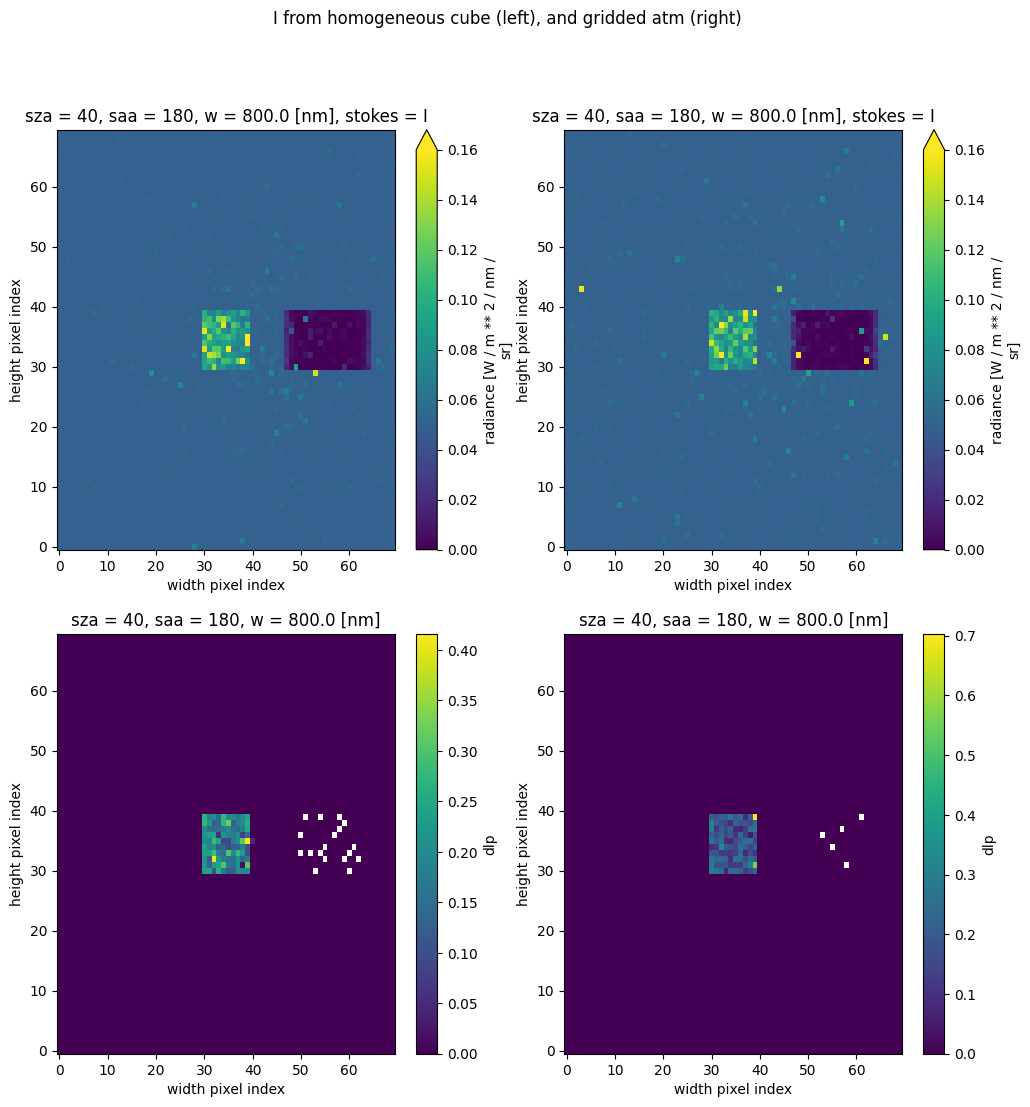

In [798]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
run1.radiance.sel(stokes="I").plot(ax=axs[0][0], vmin=0, vmax=0.16)
run2.radiance.sel(stokes="I").plot(ax=axs[0][1], vmin=0, vmax=0.16)
run1.dlp.plot(ax=axs[1][0])
run2.dlp.plot(ax=axs[1][1])
plt.suptitle("I from homogeneous cube (left), and gridded atm (right)")
plt.show()
plt.close()

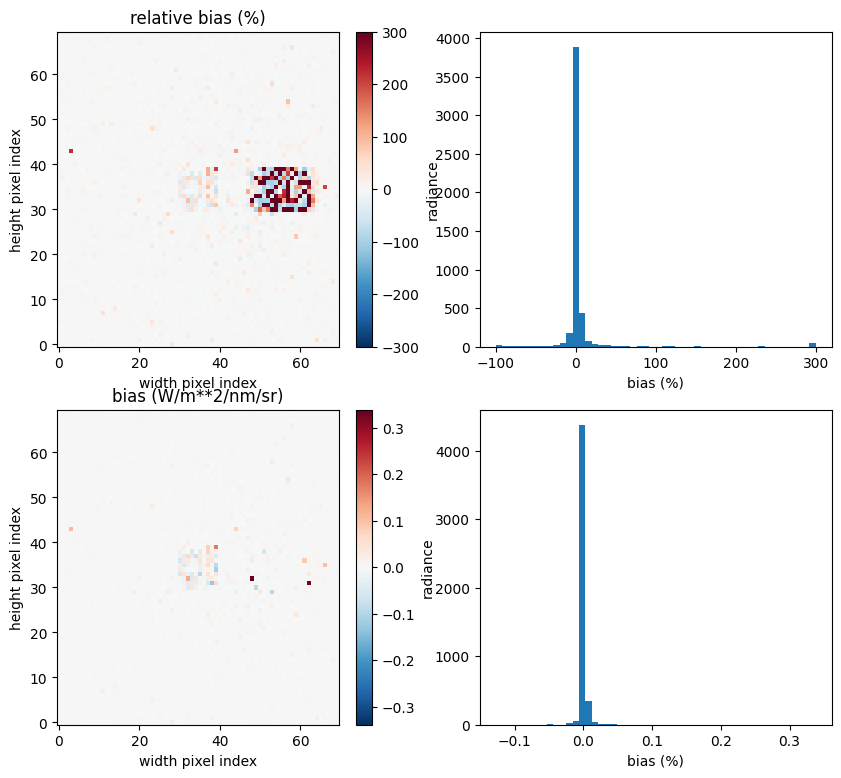

In [799]:
fig, axs = plt.subplots(2, 2, figsize=(10, 9))
rbias = ((run2.radiance - run1.radiance) / run1.radiance * 100).clip(-300, 300)
rbias.sel(stokes="I").plot(ax=axs[0][0])
axs[0][0].set_title("relative bias (%)")
axs[0][1].hist(rbias.sel(stokes="I").values.ravel(), bins=50)
axs[0][1].set_xlabel("bias (%)")
bias = run2.radiance - run1.radiance
bias.sel(stokes="I").plot(ax=axs[1][0])
axs[1][0].set_title("bias (W/m**2/nm/sr)")
axs[1][1].hist(bias.sel(stokes="I").values.ravel(), bins=50)
axs[1][1].set_xlabel("bias (%)")
plt.show()
plt.close()

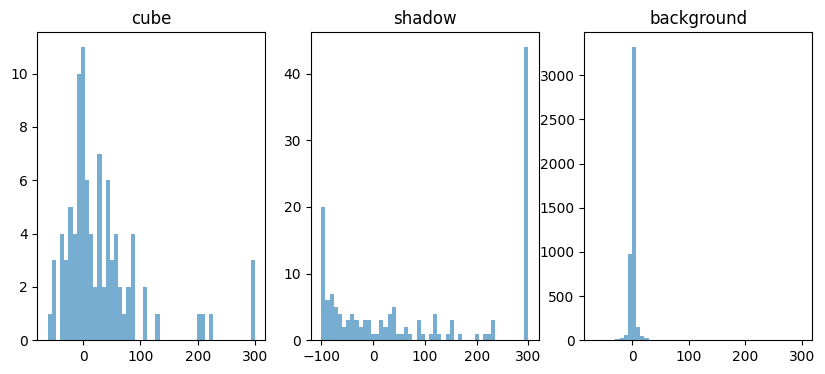

In [800]:
fig, axs = plt.subplots(1, 3, figsize=(10, 4))
icmp2 = run2.radiance.sel(stokes="I")
cube_mask = icmp2 > 0.075
bckg_mask = (icmp2 > 0.01) & ~cube_mask
shdw_mask = ~(cube_mask | bckg_mask)
axs[0].hist(rbias.sel(stokes="I").where(cube_mask).values.ravel(), bins=50, alpha=0.6)
axs[0].set_title("cube")
axs[1].hist(rbias.sel(stokes="I").where(shdw_mask).values.ravel(), bins=50, alpha=0.6)
axs[1].set_title("shadow")
axs[2].hist(rbias.sel(stokes="I").where(bckg_mask).values.ravel(), bins=50, alpha=0.6)
axs[2].set_title("background")
plt.show()
plt.close()

### 5. Comparison with Mystic on vacuum observations

In [801]:
data_mystic = np.loadtxt("./test_3d_clouds/iprt_case_c2_mystic.dat")

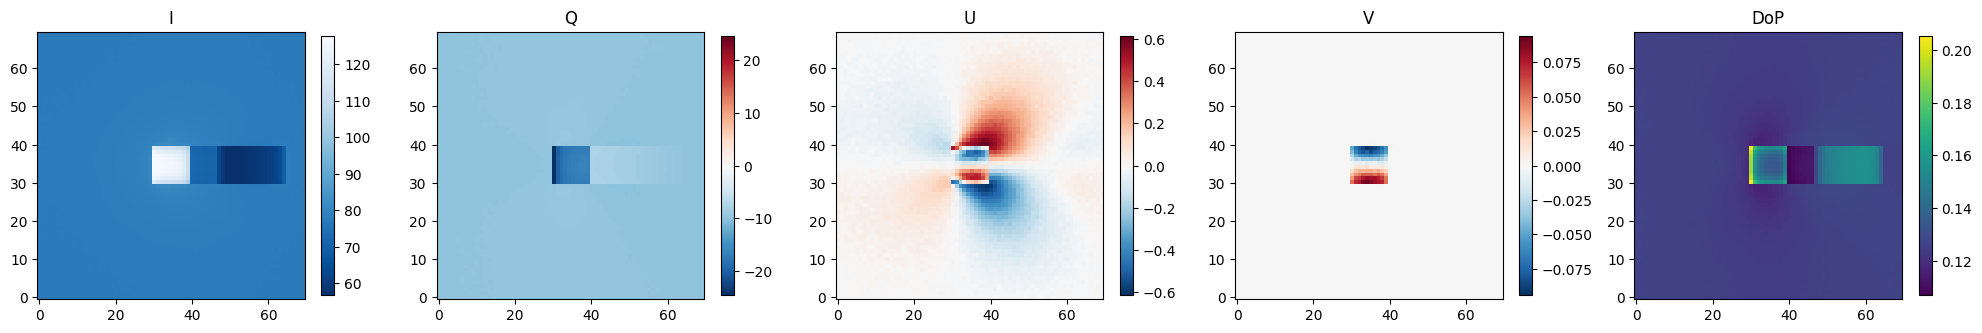


(
    <Figure size 2000x400 with 10 Axes>,
    array([<Axes: title={'center': 'I'}>, <Axes: title={'center': 'Q'}>,
       <Axes: title={'center': 'U'}>, <Axes: title={'center': 'V'}>,
       <Axes: title={'center': 'DoP'}>], dtype=object)
)

In [802]:
from test_3d_clouds import plot_stokes_from_ascii

mask = (
    (data_mystic[:, 0] == 2)  # case 1 no atmosphere, 2 atmosphere
    & (data_mystic[:, 1] == 40)  # theta0
    & (data_mystic[:, 2] == 5)  # zout
    & (data_mystic[:, 3] == 180)  # theta
    & (data_mystic[:, 4] == 0)  # phi
)

result_mystic = data_mystic[mask]

plot_stokes_from_ascii(result_mystic * 1e3)

In [803]:
mystic_df = pd.DataFrame(data=data_mystic, columns=cols + idx + values)
mystic_df = mystic_df.pivot(columns=cols, index=idx, values=values)
mystic_df["Q"]

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 mystic_df = pd.DataFrame(data=data_mystic, columns=cols + idx + values)                      │
│   2 mystic_df = mystic_df.pivot(columns=cols, index=idx, values=values)                          │
│   3 mystic_df["Q"]                                                                               │
│   4                                                                                              │
│                                                                                                  │
│ /home/miskn/.local/lib/python3.10/site-packages/pandas/core/ops/common.py:76 in new_method       │
│                                                                                                  │
│    73 │   │                                                                                      │
│    74 │   │   other = item_from_zerodim(other)                                                   │
│    75 │   │                                                                                      │
│ ❱  76 │   │   return method(self, other)                                                         │
│    77 │                                                                                          │
│    78 │   return new_method                                                                      │
│    79                                                                                            │
│                                                                                                  │
│ /home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:186 in __add__          │
│                                                                                                  │
│   183 │   │   elk       1.7     NaN                                                              │
│   184 │   │   moose     3.0     NaN                                                              │
│   185 │   │   """                                                                                │
│ ❱ 186 │   │   return self._arith_method(other, operator.add)                                     │
│   187 │                                                                                          │
│   188 │   @unpack_zerodim_and_defer("__radd__")                                                  │
│   189 │   def __radd__(self, other):                                                             │
│                                                                                                  │
│ /home/miskn/.local/lib/python3.10/site-packages/pandas/core/indexes/base.py:7304 in              │
│ _arith_method                                                                                    │
│                                                                                                  │
│   7301 │   │   │   # See https://github.com/pandas-dev/pandas/issues/31109                       │
│   7302 │   │   │   return NotImplemented                                                         │
│   7303 │   │                                                                                     │
│ ❱ 7304 │   │   return super()._arith_method(other, op)                                           │
│   7305 │                                                                                         │
│   7306 │   @final                                                                                │
│   7307 │   def _unary_method(self, op):                                                          │
│                                                                                                  │
│ /home/miskn/.local/lib/python3.10/site-packages/pandas/core

In [ ]:
def eradiate_conversion(case):
    def wrapped(ds):
        df = ds.item().to_dataframe()
        df = df.reset_index()
        # df["radiance"] /= df.irradiance.values
        df["radiance_std"] = np.sqrt(df.radiance_var)  # / df.irradiance
        df["theta"] = 180 - df.vza
        df["theta_0"] = df.sza
        df["i_x"] = df["x_index"] + 1
        df["i_y"] = df["y_index"] + 1
        df["phi"] = np.abs(df.vaa - 180)
        df = df.drop(
            [
                "vza",
                "vaa",
                "y",
                "x",
                "dlp",
                "irradiance",
                "x_index",
                "y_index",
                "w",
                "saa",
                "sza",
                "radiance_var",
            ],
            axis=1,
        )
        df = df[
            [
                "stokes",
                "radiance",
                "radiance_std",
                "phi",
                "theta",
                "theta_0",
                "i_x",
                "i_y",
            ]
        ]

        df = [
            x.rename(dict(radiance=c, radiance_std=f"{c}std"), axis=1).drop(
                ["stokes"], axis=1
            )
            for c, x in df.groupby("stokes")
        ]
        df = [x.set_index(["phi", "theta", "theta_0", "i_x", "i_y"]) for x in df]
        df = pd.concat(df, axis=1).reset_index()
        df["case"] = case
        df["z"] = 5 if ds.index[0] > "4" else 0
        return df

    return wrapped


def make_iprt_dataframe(results, case=1):
    conversion_case = eradiate_conversion(case)
    df = pd.concat(results.to_frame().apply(conversion_case, axis=1).tolist())
    df = df.pivot(columns=cols, index=idx, values=values)
    return df

In [804]:
erd_df1 = make_iprt_dataframe(c2_results, case=1)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ /home/miskn/.local/lib/python3.10/site-packages/pandas/core/indexes/base.py:3812 in get_loc      │
│                                                                                                  │
│   3809 │   │   """                                                                               │
│   3810 │   │   casted_key = self._maybe_cast_indexer(key)                                        │
│   3811 │   │   try:                                                                              │
│ ❱ 3812 │   │   │   return self._engine.get_loc(casted_key)                                       │
│   3813 │   │   except KeyError as err:                                                           │
│   3814 │   │   │   if isinstance(casted_key, slice) or (                                         │
│   3815 │   │   │   │   isinstance(casted_key, abc.Iterable)                                      │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:167                                                    │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:196                                                    │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7088                                        │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7096                                        │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyError: 'ix'

The above exception was the direct cause of the following exception:

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 erd_df1 = make_iprt_dataframe(c2_results, case=1)                                            │
│   2                                                                                              │
│                                                                                                  │
│ in make_iprt_dataframe:28                                                                        │
│                                                                                                  │
│   25 def make_iprt_dataframe(results, case=1):                                                   │
│   26 │   conversion_case = eradiate_conversion(case)                                             │
│   27 │   df = pd.concat(results.to_frame().apply(conversion_case, axis=1).tolist())              │
│ ❱ 28 │   df = df.pivot(columns=cols, index=idx, values=values)                                   │
│   29 │   return df                                                                               │
│   30                                                                                             │
│                                                                                                  │
│ /home/miskn/.local/lib/python3.10/site-packages/pandas/core/frame.py:9366 in pivot               │
│                                                                                                  │
│    9363 │   ) -> DataFrame:                                                                      │
│    9364 │   │   from pandas.core.reshape.pivot import pivot                                      │
│    9365 │   │                                                             

In [ ]:
erd_df1

In [ ]:
mystic_df.index = erd_df1.index

In [ ]:
erd_df1.loc[:, polcmps] = np.abs(erd_df1[polcmps])
mystic_df.loc[:, polcmps] = np.abs(mystic_df[polcmps])

In [ ]:
m = max(erd_df1.I.iloc[:, 4].max(), mystic_df.I.iloc[:, 4].max())

plt.colorbar(plt.imshow(erd_df1.I.iloc[:, 4].values.reshape(70, 70).T, vmin=0, vmax=m))

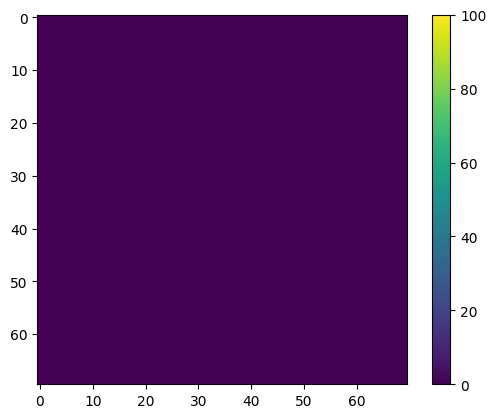

In [805]:
plt.colorbar(
    plt.imshow(mystic_df.I.iloc[:, 4].values.reshape(70, 70).T, vmin=0, vmax=m)
)

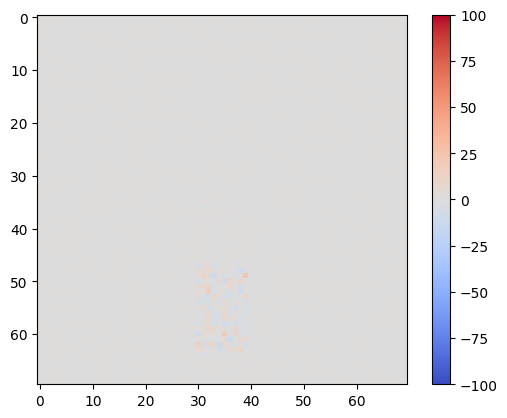

In [806]:
b = (erd_df1.I.iloc[:, 4] - mystic_df.I.iloc[:, 4]) / mystic_df.I.iloc[:, 4] * 100
m = np.max(np.abs(m))
plt.colorbar(plt.imshow(b.values.reshape(70, 70), cmap="coolwarm", vmin=-m, vmax=m))

<Axes: >

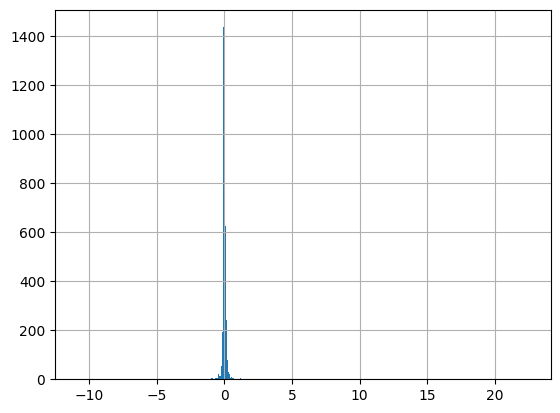

In [807]:
b.hist(bins=500)

### 6. Homogeneous atmosphere and cubic cloud case

The second batch of test for C2 includes a homogeneous atmosphere. Let's configure it.

In [808]:
from eradiate.scenes.atmosphere import GriddedHeterogeneousAtmosphere
from eradiate.scenes.phase import RayleighPhaseFunction

In [809]:
c2_geometries = pd.DataFrame(
    columns=["sza", "z", "vza", "vaa"],
    index=np.arange(1, 10, 1),
    data=[
        [20, 0, 40, 0],
        [20, 0, 40, 60],
        [20, 0, 40, 120],
        [20, 0, 40, 180],
        [40, 5, 180, 0],
        [40, 5, 140, 0],
        [40, 5, 140, 60],
        [40, 5, 140, 120],
        [40, 5, 140, 180],
    ],
).T
c2_geometries

c2_2_measures = (
    pd.concat([c2_geometries.T, c2_targets], axis=1)
    .T.apply(
        lambda x: MultiPixelDistantMeasure.from_angles(
            angles=(x.vza - 180, x.vaa),
            target=x.target,
            film_resolution=[70, 70],
            srf=DeltaSRF(c2_w_ref),
            id=str(x.name),
            ray_offset=c2_epsilon_dist if x.z < 1 else None,
            spp=c2_spp,
        )
    )
    .rename("measure")
)

In [810]:
def homogeneous_with_cubic(pbar):
    def wrapped(exp):
        hom_atm = eradiate.scenes.atmosphere.HomogeneousAtmosphere(
            geometry=c2_geom,
            sigma_s=0.5 / (5000),
            sigma_a=0.0,
        )
        hom_atm._phase = RayleighPhaseFunction(
            depolarization=np.array([0]), geometry=c2_geom
        )
        exp = AtmosphereExperiment(
            atmosphere=GriddedHeterogeneousAtmosphere(
                molecular_atmosphere=None,
                particle_layers=[c2_particle_layer],
                geometry=c2_geom,
                clouds=hom_atm,
            ),
            surface=dict(type="lambertian", reflectance=0.2),
            illumination=exp.illumination,
            geometry=c2_geom,
            integrator=dict(type=c2_integrator, stokes=True, moment=True),
            measures=exp.measures,
        )
        pbar.update()
        return exp

    return wrapped


def compute_exp(pbar, spp):
    def wrapped(exp):
        res = eradiate.run(exp, spp=spp)
        pbar.update()
        return res

    return wrapped

In [811]:
with tqdm(range(9)) as pbar:
    c2_2_experiments = c2_experiments.apply(homogeneous_with_cubic(pbar))

  0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
%%time
import drjit as dr

dr.set_thread_count(16)
with tqdm(range(9)) as pbar:
    c2_2_results = c2_2_experiments.apply(compute_exp(pbar, spp=c2_spp))
dr.set_thread_count(23)

In [344]:
make_iprt_panel_plot(c2_2_results)

plt.tight_layout()

print("Save pdf...")

plt.savefig("c2_2_iprt_panel.pdf", format="pdf")
plt.savefig("c2_2_iprt_panel.png")

print("Output images...")

plt.show()
plt.close()

print("Done.")

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱  1 make_iprt_panel_plot(c2_2_results)                                                          │
│    2                                                                                             │
│    3 plt.tight_layout()                                                                          │
│    4                                                                                             │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'c2_2_results' is not defined

In [ ]:
erd_df2 = make_iprt_dataframe(c2_2_results, case=2)

In [ ]:
erd_df2

In [ ]:
erd_df = pd.concat([erd_df1, erd_df2], axis=1)

In [ ]:
case_index = pd.MultiIndex.from_product(
    [[1, 2], list(range(1, 10))], names=["<atmosphere>", "<geometry>"]
)

In [ ]:
import seaborn as sns

for cmp in ["I", *polcmps]:
    imean_mystic = mystic_df[cmp].T * 1e3
    imean_mystic = imean_mystic.where(imean_mystic != 0)
    imean_mystic.index = case_index
    imean_mystic = imean_mystic.T.abs().mean().rename("MYSTIC")
    imean_erd = erd_df[cmp].T * 1e3
    imean_erd = imean_erd.where(imean_erd != 0)
    imean_erd.index = case_index
    imean_erd = imean_erd.T.abs().mean().rename("ERADIATE")

    plt.figure(figsize=(18, 2))
    sns.heatmap(
        pd.concat([imean_erd, imean_mystic], axis=1).T, cmap="Blues_r", annot=True
    )
    plt.title(f"|{cmp}| mean ($\\times 10^3$)")
    plt.show()
    plt.close()

In [ ]:
for cmp in ["I", *polcmps]:
    std_mystic = mystic_df[cmp].T
    std_mystic.index = case_index
    std_mystic = std_mystic.where(std_mystic != 0)
    std_mystic = std_mystic.T.std().rename("MYSTIC") / std_mystic.T.mean().values * 100
    std_erd = erd_df[cmp].T
    std_erd.index = case_index
    std_erd = std_erd.where(std_erd != 0)
    std_erd = std_erd.T.std().rename("ERADIATE") / std_erd.T.mean().values * 100

    plt.figure(figsize=(18, 2))
    sns.heatmap(pd.concat([imean_erd, imean_mystic], axis=1).T, cmap="YlGn", annot=True)
    plt.title(f"$\\sigma_{{rel}}^{cmp}$")
    plt.show()
    plt.close()

In [ ]:
def rmse(v1, v2):
    v1 = v1[v2 != 0]
    v2 = v2[v2 != 0]
    return np.sqrt(np.mean((v1 - v2) ** 2)) / v2.mean() * 100

In [ ]:
def corr_metric(df1, df2, scmp, method="pearson"):
    return (
        df1[scmp]
        .T.reset_index()
        .T.corrwith(df2[scmp].T.reset_index().T, method=method)
        .to_frame()
        .set_index(df2[scmp].T.index)[0]
        .rename(scmp)
    )

In [ ]:
def rbias(v1, v2):
    v1 = v1[v2 != 0]
    v2 = v2[v2 != 0]
    return ((v1 - v2) / v2 * 100).mean()

In [ ]:
cor = pd.concat(
    [corr_metric(erd_df, mystic_df, scmp) for scmp in ["I", "Q", "U", "V", "Istd"]],
    axis=1,
).reset_index(drop=True)
cor.index = case_index
sns.heatmap(cor, cmap="coolwarm", vmin=-1, vmax=1, annot=True)

In [ ]:
plt.figure(figsize=(18, 4))
drmse = pd.concat(
    [
        corr_metric(erd_df, mystic_df, scmp, method=rmse)
        for scmp in ["I", "Q", "U", "V"]
    ],
    axis=1,
).reset_index(drop=True)
drmse.index = case_index
sns.heatmap(drmse.T, cmap="Reds", vmin=0, annot=True)
plt.title("Relative RMSE")

In [ ]:
plt.figure(figsize=(18, 1))
bias = pd.concat(
    [
        corr_metric(erd_df, mystic_df, scmp, method=rbias)
        for scmp in ["I", "Q", "U", "V"]
    ],
    axis=1,
).reset_index(drop=True)
bias.index = case_index
sns.heatmap(bias[["I"]].T, cmap="Oranges", vmin=0, annot=True)

In [ ]:
sel_c2_2_5 = (2.0, 40.0, 5.0, 180.0)
mystic_c2_2_5 = mystic_df.I[sel_c2_2_5].values.reshape(70, 70)
erd_c2_2_5 = erd_df.I[sel_c2_2_5].values.reshape(70, 70)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

b = (erd_c2_2_5 - mystic_c2_2_5) / mystic_c2_2_5 * 100
m = np.abs(b).max()
plt.colorbar(ax1.imshow(b, vmin=-m, vmax=m))

_ = ax2.hist(b.ravel(), bins=500)
plt.grid()

## V. A proper cloud interface

Using particle layers to fill Eradiate extinction coefficient grids is feasible, but lacks proper support for intrinsic cloud properties. It lets users handle important pre-processing steps at the core of the scope of Eradiate and this is not sufficient. Spatially varying phase functions due to cloud particles effective radius and effective radius variance interpolation would also lack support.

### 1. Loading, preprocessing

Source cloud properties can be defined as follows:
 - a cloud profile, composed of gamma distribution parameters R_eff (effective radius) and V_eff (effective variance) define on the atmospheric grid spatial extent.
 - a cloud presence metric, defined by the LWC.
 - cloud material properties, depending on the observed species (water).

From IPRT case C3:

In [ ]:
mie_ws = xr.load_dataset("test_3d_clouds/watercloud_670.mie.cdf")
mie_ws

The provided format is a ragged array of phase function defined on incompatible irregular angular grids. Preprocessing in this situation must be handled with care to avoid:
 - unnecessary padding (the data is large enough)
 - excessive grid stitching, leading to much more memory usage
 - unvectorized implementation of the interpolation
 - approximations
 - aliazing when mapping the interpolated properties onto a regular spatial grid.

The proposed solution develops an intermediate polarized phase function dataset format, contiguous in memory with a sparse representation. Each phase is thus defined on its own minimal grid, minimizing memory costs. The implementation is reasonably optimized to allow subsecond evaluation of the C3 set of phase functions. The contiguous nature facilitates loading of the data and avoid unnecessary copies of complex structures, all the while limiting fragmentation. 

It's not perfect though, this approach still consumes a large amount of memory. It could be optimized to provide a specific variant for spherical and spheroidal shapes. The tradeoff of interpolating against R_eff and V_eff at integration time in Mitsuba has not been evaluated. An attempt was made to use legendre space interpolation, leading to excessive time being spent in coefficients evaluation.

In [ ]:
phase_da = mie_ws.phase
_ = plt.hist(phase_da.values.ravel(), bins=50)

For the general case in Eradiate we need to encode the 16 Mueller matrix components, even though it is not necessary for the spherical particles of the case C3. Phase function backscattering peaks can reach very high values > 30k, this breaks the physicality of the scene. In practice the peak is never directly sampled at a scattering angle of 0°, unless we build an artificial scene to do this (directional irradiance and directional observation exactly at the backscattering position). 

In [ ]:
from eradiate.scenes.phase import format_cloudparticles_dataset

# Only 1 v_eff value is used in this dataset, equal to 1/9.
wc_ds = format_cloudparticles_dataset(mie_ws, [1 / 9])
wc_ds

The proposed solution uses a single index for the entire dataset of phase function points (total_pts). The data variables start and n_pts provide the necessary segmentation points of this large array. This representation avoid padding in the data and provides constant access to any specific phase function. However, this is still not interpolated against a specific set of cloud physical properties (r_eff, v_eff) or observation wavelength.

In [ ]:
def load_profile(cumulus_path, v_eff=1 / 9):
    """Read the cumulus .dat file and return cumulus_profile (xr.Dataset)."""
    import pandas as pd

    df = pd.DataFrame(
        data=np.loadtxt(cumulus_path, skiprows=3),
        columns=["i_x", "i_y", "i_z", "extinction", "r_eff"],
    )
    df[["i_x", "i_y", "i_z"]] = df[["i_x", "i_y", "i_z"]].astype(int)
    n_x, n_y, n_z = np.loadtxt(cumulus_path, skiprows=1, max_rows=1, usecols=(0, 1, 2))
    x_r, y_r = np.loadtxt(cumulus_path, skiprows=2, max_rows=1, usecols=(0, 1))
    z_levels = np.loadtxt(cumulus_path, skiprows=2, max_rows=1)[2:]
    df["v_eff"] = float(v_eff)
    ds = df.to_xarray()

    ds = xr.merge(
        [
            ds,
            xr.Dataset(
                coords=dict(
                    x=(["x"], np.arange(0, n_x + 1, 1, dtype=int)),
                    y=(["y"], np.arange(0, n_y + 1, 1, dtype=int)),
                    z=(["z"], np.arange(0, n_z + 1, 1, dtype=int)),
                ),
                data_vars=dict(
                    x_levels=(
                        ["x"],
                        np.arange(0, x_r * n_x * 1.01, x_r),
                        dict(units="km"),
                    ),
                    y_levels=(
                        ["y"],
                        np.arange(0, y_r * n_y * 1.01, y_r),
                        dict(units="km"),
                    ),
                    z_levels=(["z"], z_levels, dict(units="km")),
                ),
            ),
        ]
    )

    return ds

In [ ]:
cu_profile = load_profile("test_3d_clouds/cumulus.dat")

Here we provide the following profile loading/formatting function, but do not include it in the delivery. This is a proposal format for this profile, and it may be documented. Just like the phase function properties, it is indexed on a single variable to take advantage of sparsity. Besides, this dataset doesn't really need an inverse index to retrieve the properties of a grid cell from its position, all grid cells are always treated sequentially in order of memory position. This also means that preprocessing of the dataset to order the cells by r_eff and v_eff can improve interpolation performances. This latter optimization is not implemented.

### 2. Configuring a cloud field

In [ ]:
from eradiate.scenes.atmosphere import CloudField

We need a few bits of setup:

In [ ]:
from eradiate.units import unit_registry as ureg

w = np.array([0.670]) * ureg.micron

In [350]:
cu_profile

<xarray.Dataset> Size: 1MB
Dimensions:     (index: 20435, x: 101, y: 101, z: 54)
Coordinates:
  * index       (index) int64 163kB 0 1 2 3 4 ... 20430 20431 20432 20433 20434
  * x           (x) int64 808B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99 100
  * y           (y) int64 808B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99 100
  * z           (z) int64 432B 0 1 2 3 4 5 6 7 8 ... 45 46 47 48 49 50 51 52 53
Data variables:
    i_x         (index) int64 163kB 1 1 1 1 1 1 1 ... 100 100 100 100 100 100
    i_y         (index) int64 163kB 2 2 2 2 2 2 2 ... 99 99 100 100 100 100 100
    i_z         (index) int64 163kB 16 17 18 19 20 21 22 ... 24 19 20 21 22 23
    extinction  (index) float64 163kB 47.89 63.11 71.67 ... 74.34 91.24 87.95
    r_eff       (index) float64 163kB 7.05 8.11 8.65 8.7 ... 7.04 8.81 9.79 9.6
    v_eff       (index) float64 163kB 0.1111 0.1111 0.1111 ... 0.1111 0.1111
    x_levels    (x) float64 808B 0.0 0.0667 0.1334 0.2001 ... 6.537 6.603 6.67
    y_levels    (y) float64 808B 0.0 0.0667 0.1334 0.2001 ... 6.537 6.603 6.67
    z_levels    (z) float64 432B 0.0 0.2 0.4 0.6 0.8 ... 15.0 20.0 25.0 30.0

In [ ]:
cfield = CloudField(
    profile=cu_profile,
    properties=wc_ds,
    particles_interp_method="nearest",  # Bilinear is supported, but is too heavy for this first test
)

The CloudField class handles profile interpolation against the grid using a nearest neighbor method by default, and the particles properties interpolation against the profile using a trilinear method. It is possible to control how the R_eff and V_eff coordinates are interpolated using the particles_interp_method set to bilinear or nearest. Nearest is an approximation that drastically reduces memory consumption at a cost in terms of accuracy

The cloud profile must be evaluated on a regular grid in Mitsuba. This is very expensive in memory for no good reason. Another optimization to implement would allow a coordinate texture lookup in Mitsuba. This is not implemented yet, as a result, the profile is indexed on each cell of the vertical extent, descretized following the Shannon Nyquist theorem.

In [ ]:
cfield = cfield.to_profile_regular_grid()  # inefficient sampling
cfield.geometry.grid.shape

Only the index is duplicated on most of the 1500 layers, not the profile values, but we still pay a price for this

In [ ]:
from eradiate.scenes.geometry import WrapMode

cfield = attrs.evolve(
    cfield, geometry=attrs.evolve(cfield.geometry, wrap_mode=WrapMode.REPEAT)
)

Just like case C2, the WrapMode allows to implement periodic boundary conditions in the atmosphere without any additional cost.

/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:138: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]))


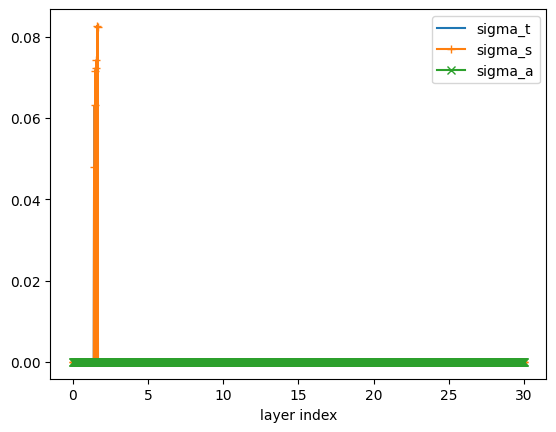

In [345]:
si = MonoSpectralIndex(w=w.item())
sigma_t = cfield.eval_sigma_t(si).m_as("m**-1")
sigma_s = cfield.eval_sigma_s(si).m_as("m**-1")
sigma_a = cfield.eval_sigma_a(si).m_as("m**-1")
albedo = cfield.eval_albedo(si)

plt.plot(cfield.geometry.grid.layers.m, sigma_t[0, 1, :], label="sigma_t")
plt.plot(cfield.geometry.grid.layers.m, sigma_s[0, 1, :], label="sigma_s", marker="+")
plt.plot(cfield.geometry.grid.layers.m, sigma_a[0, 1, :], label="sigma_a", marker="x")
plt.xlabel("layer index")
plt.legend()

As expected, cloud absorption on an arbitrary selected column is close to zero. Scattering increases on cloud filled cells.

### 3. Test case: C3 clouds in the void, nadir obseration

Before delving into more complicated and expensive cases, a simpler one is defined. It is base on IPRT C3 at nadir observation direction (geometry 5). The molecular atmosphere and aerosols are not included. Only a single scattering event is allowed.

In [582]:
sza = 40 * ureg.degree

target = {
    "type": "rectangle",
    "xmin": -3.385e3,
    "xmax": 3.385e3,
    "ymin": -3.385e3,
    "ymax": 3.385e3,
    "z": 0,
}

scene_config = dict(
    geometry=cfield.geometry,
    surface={
        "type": "basic",
        "shape": {"type": "rectangle", "edges": [1e9, 1e9]},
        "bsdf": {"type": "lambertian", "reflectance": 0.2},
    },
    measures=[
        MultiPixelDistantMeasure.from_angles(
            angles=(0, 0),
            target=target,
            film_resolution=[100, 100],
            srf=DeltaSRF(si.w),
            id="test_cumulus",
            ray_offset=None,
            spp=1,
        ),
    ],
    illumination={
        "type": "directional",
        "irradiance": 1 / np.cos(sza.m_as("radian")),
        "zenith": sza,
        "azimuth": 180 * ureg.degree,
    },
    integrator={
        "type": "eovolpath",
        "moment": True,
        "stokes": True,
    },
)

These parameters will be reused.

In [583]:
from eradiate.experiments import AtmosphereExperiment
from eradiate.scenes.measure import MultiPixelDistantMeasure, PerspectiveCameraMeasure
from eradiate.spectral import DeltaSRF

single_scattering_experiment = AtmosphereExperiment(
    atmosphere=GriddedHeterogeneousAtmosphere(
        clouds=cfield,
        molecular_atmosphere=None,
        particle_layers=[],
        geometry=cfield.geometry,
    ),
    **scene_config,
)
single_scattering_experiment.integrator.max_depth = 2

In [584]:
%%time

dr.set_thread_count(23)
# ~10min for SPP=1000

res_void = eradiate.run(single_scattering_experiment, spp=100)

/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:138: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]))


CPU times: user 1h 42min 7s, sys: 2.36 s, total: 1h 42min 9s
Wall time: 5min 35s


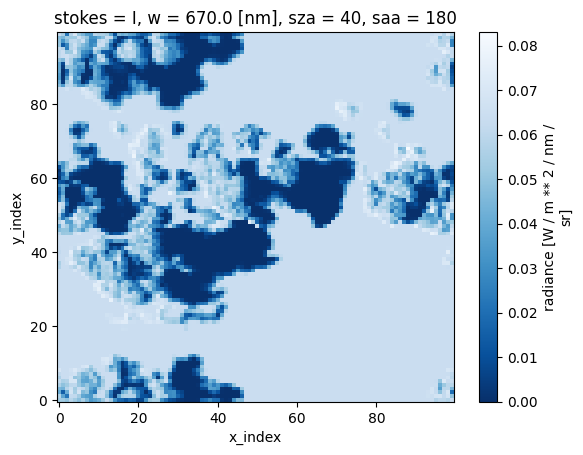

In [587]:
res_void.radiance.sel(stokes="I").squeeze().plot(cmap="Blues_r")

### 4. Defining the heterogeneous atmosphere components

The actual IPRT C3 features two atmospheric compositions, one with a molecular atmosphere (case 1), and another with a molecular atmosphere and aerosols (case 2).

Let's start with the aerosol dataset, using the conversion function provided by emdec.

In [588]:
from test_3d_clouds.utils import load_aerosol_data

aerosol_ds = load_aerosol_data("test_3d_clouds/waso_670.mie.cdf", "spherical", w.item())

The following cells load the IPRT profiles into eradiate objects. This is a bit tedious

In [589]:
from eradiate.radprops import ArrayRadProfile
from eradiate.scenes.atmosphere import (
    ArrayParticleDistribution,
    MolecularAtmosphere,
    ParticleLayer,
)

grid = cfield.geometry.grid

In [590]:
df = pd.read_csv(
    "test_3d_clouds/atmos_ext_cu.dat",
    escapechar="!",
    sep="\s+",
    skiprows=6,
).iloc[:, :-1]
df.columns = [
    "height",
    "temp",
    "molabs1",
    "molabs2",
    "molabs3",
    "rayleigh",
    "aerext1",
    "aerext2",
]
df_ext = df.sort_values("height").reset_index(drop=True)

In [718]:
df = pd.read_csv(
    "test_3d_clouds/atmos_tau_cu.dat",
    escapechar="!",
    sep="\s+",
    skiprows=6,
).iloc[:, :-1]
df.columns = [
    "bottom",
    "top",
    "temp",
    "absot1",
    "absot2",
    "absot3",
    "scaot",
    "aot1",
    "aot2",
]
df_tau = df.sort_values("bottom", ascending=True).reset_index(drop=True)

In [631]:
def load_atmosphere_data(data_path, wavelength, ic) -> xr.DataArray:
    
    atmosphere_data = np.loadtxt(data_path, skiprows=7)
    w = [wavelength - 5, wavelength + 5]

    # put twice the same data to enable interpolation
    data=np.zeros((2, len(atmosphere_data[:,ic])+1))
    #print(data.shape, atmosphere_data[:,ic].shape)
    data[0,1:-1] = atmosphere_data[1:,ic]  
    data[1,1:-1] = atmosphere_data[1:,ic] 
    
    z = np.zeros(len(atmosphere_data[:,0])+1)
    z_level=atmosphere_data[:,0]
    z[1:-1] = z_level[:-1]-0.5*(z_level[:-1]-z_level[1:])
    z[-1]=0.0
    z[0]=30.0
    
    data[0,1:-1]/=(z_level[:-1]-z_level[1:])
    data[1,1:-1]/=(z_level[:-1]-z_level[1:])
    data[:,0]=data[:,1]
    data[:,-1]=data[:,-2]

    z=z[::-1]
    data=data[:,::-1]
    
    return xr.DataArray(
        data=data,
        dims=["w", "z"],
        coords={
            "w": ("w", w, {"description": "wavelength", "units": "nm"}),
            "z": ("z", z, {"description": "altitude", "units": "km"}),
        },
        attrs={"description": "scattering/absorption coefficient", "units": "1/km"},
    )

test_sigma_s = load_atmosphere_data("test_3d_clouds/atmos_tau_cu.dat", 670, 6)
test_sigma_a = load_atmosphere_data("test_3d_clouds/atmos_tau_cu.dat", 670, 3)

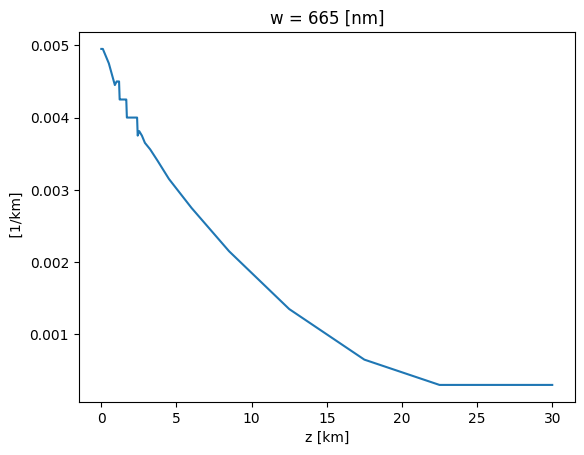

In [636]:
test_sigma_s.isel(w=0).plot()

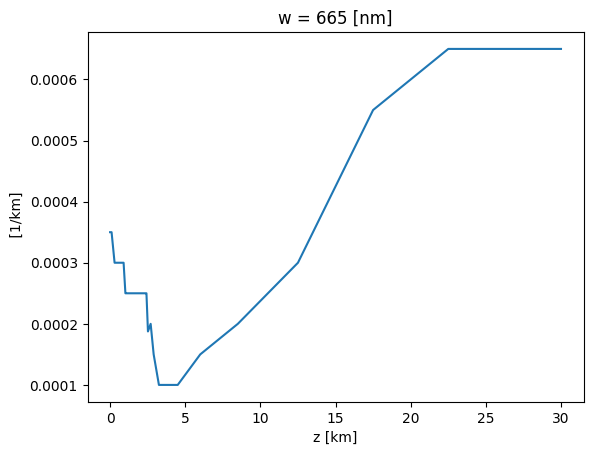

In [637]:
test_sigma_a.isel(w=0).plot()

In [753]:
df_ext_sorted = df_ext.sort_values("height").reset_index(drop=True)
z_levels = df_ext_sorted.height.values
ws = np.asarray([0.665, 0.675])
mol_coords = dict(
    w=(["w"], ws, dict(units="micron")), z=(["z"], z, dict(units="km"))
)

sigma_s = xr.Dataset(
    coords=mol_coords,
    data_vars=dict(
        sigma_s=(
            ["w", "z"],
            np.repeat(np.atleast_2d(st), 2, axis=0),
            dict(units="1/km"),
        )
    ),
).sigma_s

sigma_a = xr.Dataset(
    coords=mol_coords,
    data_vars=dict(
        sigma_a=(
            ["w", "z"],
            np.repeat(np.atleast_2d(at), 2, axis=0),
            dict(units="1/km"),
        )
    ),
).sigma_a


In [777]:

radprops = ArrayRadProfile(
    sigma_a=sigma_a,
    sigma_s=sigma_s,
    rayleigh_depolarization=np.asarray([0.0]),
    interpolation_method="linear",
)
ma = MolecularAtmosphere(
    geometry=cfield.geometry,
    thermoprops=None,
    radprops_profile=radprops,
)

df_tau_sorted = df_tau.sort_values("bottom").reset_index(drop=True)
layer_center_km = 0.5 * (df_tau_sorted.bottom.values + df_tau_sorted.top.values)
coords_normalized = layer_center_km / 30.0
tau_aer_per_layer = df_tau_sorted.aot1.values

distribution = ArrayParticleDistribution(
    values=tau_aer_per_layer,
    coords=coords_normalized,
    method="linear",
    extrapolate="nearest",
)

particles = ParticleLayer(
    geometry=cfield.geometry,
    bottom=0.0 * ureg.km,
    top=30.0 * ureg.km,
    distribution=distribution,
    w_ref=0.67 * ureg.micron,
    tau_ref=float(tau_aer_per_layer.sum()),
    dataset=aerosol_ds,
)

/home/miskn/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


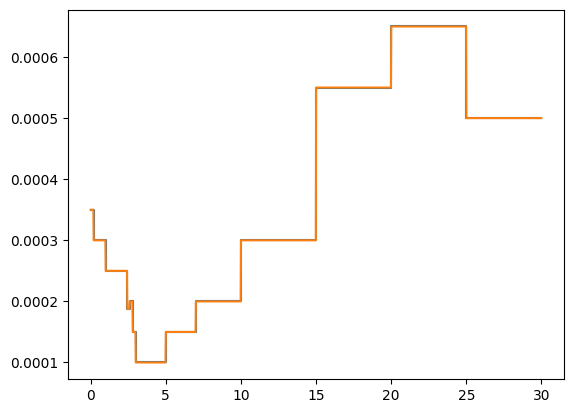

In [778]:
df_tau["top_e"] = np.nextafter(df_tau.top, -np.inf)
z = df_tau[["bottom", "top_e"]].values.ravel()
h = (df_tau.top - df_tau.bottom)
h = np.tile(h.values, (2, 1)).T.ravel()
at = np.tile(df_tau.absot1.values, (2, 1)).T.ravel() / h


plt.plot(z, at)
plt.plot(ma.geometry.grid.layers, ma.eval_sigma_a(MonoSpectralIndex(w=670*ureg.nm)))

/home/miskn/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


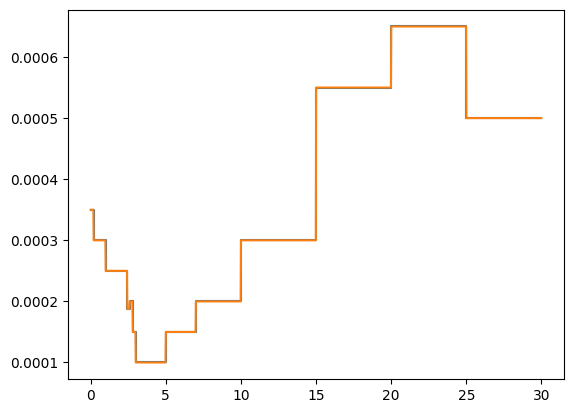

In [779]:
df_tau["top_e"] = np.nextafter(df_tau.top, -np.inf)
z = df_tau[["bottom", "top_e"]].values.ravel()
h = (df_tau.top - df_tau.bottom)
h = np.tile(h.values, (2, 1)).T.ravel()
at = np.tile(df_tau.absot1.values, (2, 1)).T.ravel() / h


plt.plot(z, at)
plt.plot(ma.geometry.grid.layers, ma.eval_sigma_a(MonoSpectralIndex(w=670*ureg.nm)))

/home/miskn/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


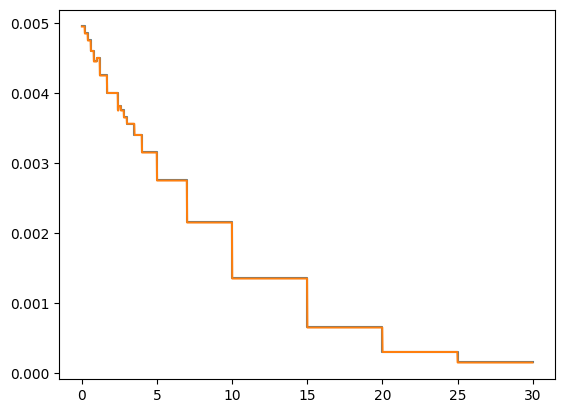

In [780]:
df_tau["top_e"] = np.nextafter(df_tau.top, -np.inf)
z = df_tau[["bottom", "top_e"]].values.ravel()
h = (df_tau.top - df_tau.bottom)
h = np.tile(h.values, (2, 1)).T.ravel()
st = np.tile(df_tau.scaot.values, (2, 1)).T.ravel() / h


plt.plot(z, st)
plt.plot(ma.geometry.grid.layers, ma.eval_sigma_s(MonoSpectralIndex(w=670*ureg.nm)))

/home/miskn/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


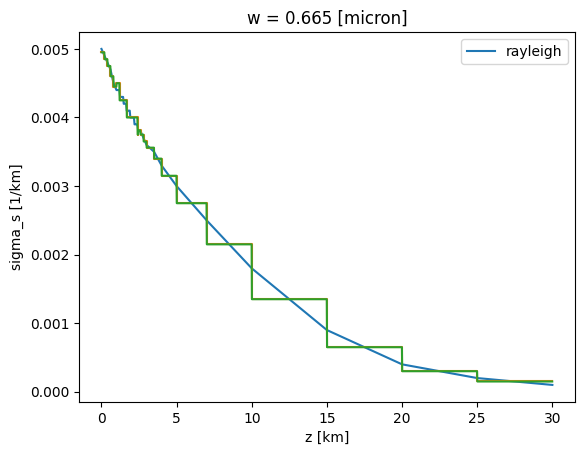

In [781]:
df_ext.plot(x="height", y="rayleigh")
sigma_s.isel(w=0).plot()
plt.plot(ma.geometry.grid.layers, ma.eval_sigma_s(MonoSpectralIndex(670 * ureg.nm)))

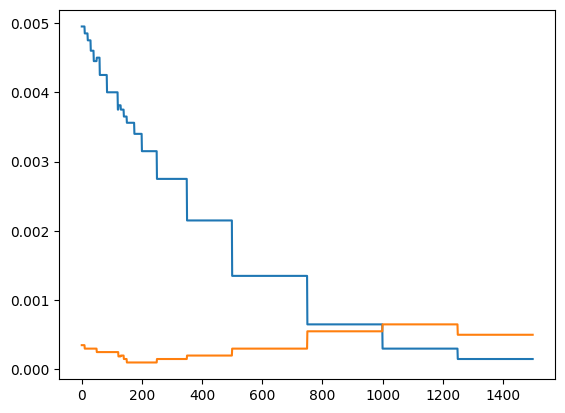

In [782]:
plt.plot(ma.eval_sigma_s(MonoSpectralIndex(670 * ureg.nm)))
plt.plot(ma.eval_sigma_a(MonoSpectralIndex(670 * ureg.nm)))

/home/miskn/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


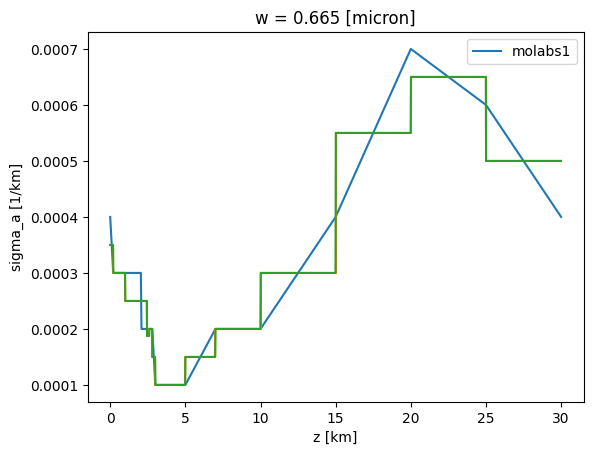

In [783]:
df_ext.plot(x="height", y="molabs1")
sigma_a.isel(w=0).plot()
plt.plot(ma.geometry.grid.layers, ma.eval_sigma_a(MonoSpectralIndex(670 * ureg.nm)))

In [784]:
experiment_noaer = AtmosphereExperiment(
    atmosphere=GriddedHeterogeneousAtmosphere(
        clouds=None,
        molecular_atmosphere=ma,
        particle_layers=[],
        geometry=cfield.geometry,
    ),
    **scene_config,
)

In [785]:
experiment_nocloud = AtmosphereExperiment(
    atmosphere=GriddedHeterogeneousAtmosphere(
        clouds=None,
        molecular_atmosphere=ma,
        particle_layers=[particles],
        geometry=cfield.geometry,
    ),
    **scene_config,
)

We actually run an experiments with only the atmosphere and no clouds to ensure the properties are correct and can somewhat be mapped to Mystic outputs on cloud free, shadow free pixels

In [786]:
%%time
# ~ 8 sec for spp = 1000
dr.set_thread_count(23)
res_noaer = eradiate.run(experiment_noaer, spp=100)
dr.set_thread_count(23)

CPU times: user 11.7 s, sys: 3.04 s, total: 14.7 s
Wall time: 6.48 s


In [787]:
%%time
# ~ 15 sec for spp = 1000
dr.set_thread_count(23)
res_nocloud = eradiate.run(experiment_nocloud, spp=100)
dr.set_thread_count(23)

CPU times: user 26 s, sys: 8.81 s, total: 34.8 s
Wall time: 15.4 s


For this we need the actual reference values

In [788]:
mdf = pd.read_csv("test_3d_clouds/iprt_case_c3_mystic.dat", sep="\s+", header=2)
cols = mdf.columns[1:]
mdf = mdf.iloc[:, :-1].copy()
mdf.columns = cols

In [789]:
m_nrad = (
    mdf[(mdf.case == 1) & (mdf.theta_0 == 40) & (mdf.theta == 180)]
    .I.values.reshape(100, 100)
    .T
)
m_nrad2 = (
    mdf[(mdf.case == 2) & (mdf.theta_0 == 40) & (mdf.theta == 180)]
    .I.values.reshape(100, 100)
    .T
)

In [790]:
m_nrad[20:40, 60:80].mean(), m_nrad[20:40, 60:80].std() * 3

(np.float64(0.0533665825), np.float64(0.0009012487868473115))

In [791]:
irr = res_noaer.irradiance.item()
test_nrad1 = res_noaer.radiance.sel(stokes="I").values / irr
test_nrad2 = res_nocloud.radiance.sel(stokes="I").values / irr

In [792]:
test_nrad1.mean(), test_nrad1.std() * 3

(np.float64(0.06478074338547886), np.float64(0.006928148817960349))

In [793]:
test_nrad2.mean(), test_nrad2.std() * 3

(np.float64(0.07116889892704786), np.float64(0.014166347063587428))

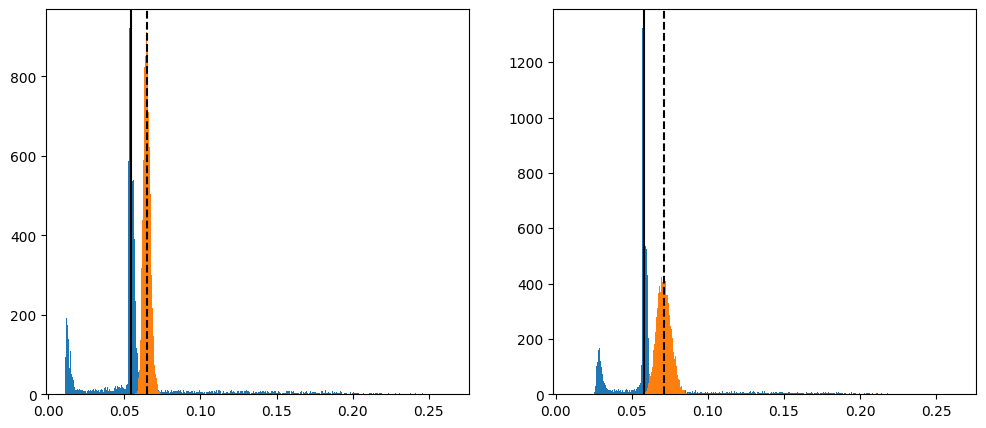

In [794]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

counts, bins, c = ax1.hist(m_nrad.ravel(), bins=500)
ax1.hist(test_nrad1.ravel(), bins=bins)
med1, m_med1 = np.median(test_nrad1), np.median(m_nrad)
ax1.axvline(m_med1, color="black")
ax1.axvline(med1, color="black", linestyle="--")

ax2.hist(m_nrad2.ravel(), bins=bins)
ax2.hist(test_nrad2.ravel(), bins=bins)
med2, m_med2 = np.median(test_nrad2), np.median(m_nrad2)
ax2.axvline(m_med2, color="black")
ax2.axvline(med2, color="black", linestyle="--")
plt.show()
plt.close()

In [795]:
(med1 - m_med1) / m_med1 * 100, (med2 - m_med2) / m_med2 * 100

(np.float64(18.59468907482968), np.float64(22.286346536573635))

The shift between the non cloud pixels and the clear sky simulation is a bug. The bias between the non cloud, non shadow pixels is about 20%, way too high.

### 5. C3 3D clouds with an atmosphere

In [ ]:
experiment_cloud1 = AtmosphereExperiment(
    atmosphere=GriddedHeterogeneousAtmosphere(
        clouds=cfield,
        molecular_atmosphere=ma,
        particle_layers=[],
        geometry=cfield.geometry,
    ),
    **scene_config,
)

experiment_cloud2 = AtmosphereExperiment(
    atmosphere=GriddedHeterogeneousAtmosphere(
        clouds=cfield,
        molecular_atmosphere=ma,
        particle_layers=[particles],
        geometry=cfield.geometry,
    ),
    **scene_config,
)

In [317]:
import datetime

In [ ]:
%%time

# ~ 8 min for spp=24
res1 = eradiate.run(experiment_cloud1, spp=6000)
ts = datetime.datetime.isoformat(datetime.datetime.now())
res1.to_netcdf(f"results/complete_c3_1_5_{ts}.nc")

/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:138: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]))


In [ ]:
%%time

# ~ 8 min for spp=24

res2 = eradiate.run(experiment_cloud2, spp=6000)
ts = datetime.datetime.isoformat(datetime.datetime.now())
res2.to_netcdf(f"results/complete_c3_2_5_{ts}.nc")

In [325]:
nres1 = res1.radiance.sel(stokes="I").values.squeeze()
nres2 = res2.radiance.sel(stokes="I").values.squeeze()

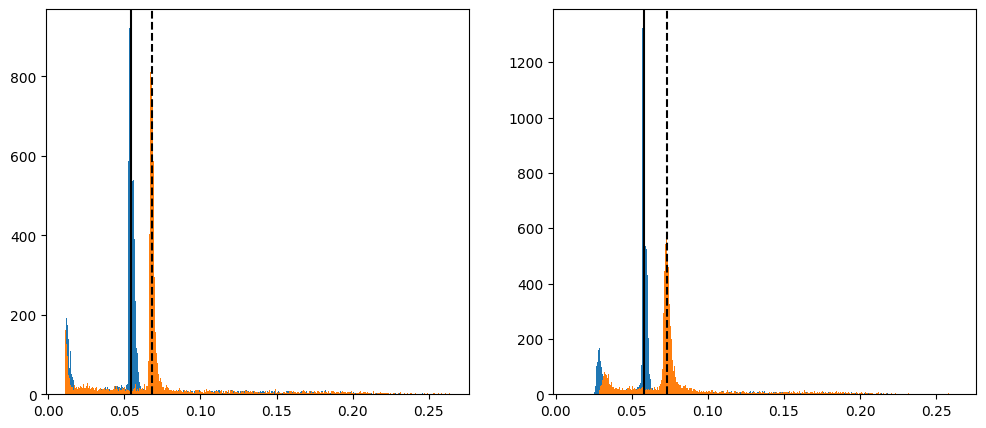

In [340]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

counts, bins, c = ax1.hist(m_nrad.ravel(), bins=500)
ax1.hist(nres1.ravel(), bins=bins)
med1, m_med1 = np.median(nres1), np.median(m_nrad)
ax1.axvline(m_med1, color="black")
ax1.axvline(med1, color="black", linestyle="--")

ax2.hist(m_nrad2.ravel(), bins=bins)
ax2.hist(nres2.ravel(), bins=bins)
med2, m_med2 = np.median(nres2), np.median(m_nrad2)
ax2.axvline(m_med2, color="black")
ax2.axvline(med2, color="black", linestyle="--")
plt.show()
plt.close()

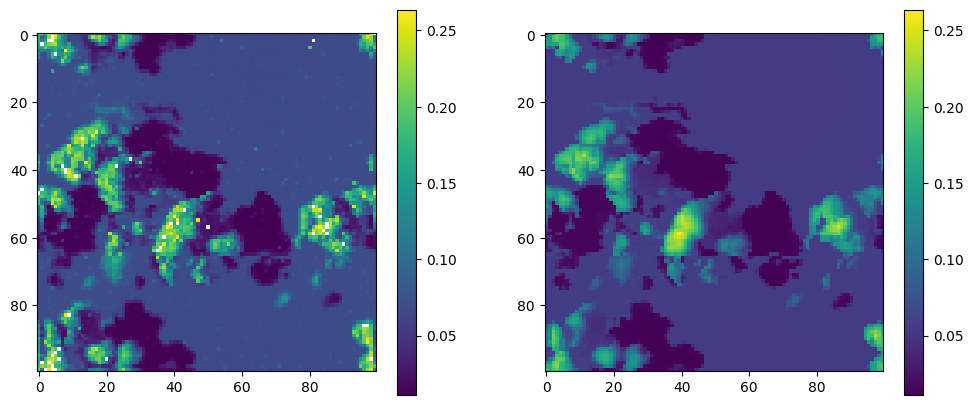

In [341]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

inrange = np.where(nres1 < m_nrad.max(), nres1, np.nan)
plt.colorbar(ax1.imshow(inrange, vmin=m_nrad.min(), vmax=m_nrad.max()))
plt.colorbar(ax2.imshow(m_nrad, vmin=m_nrad.min(), vmax=m_nrad.max()))

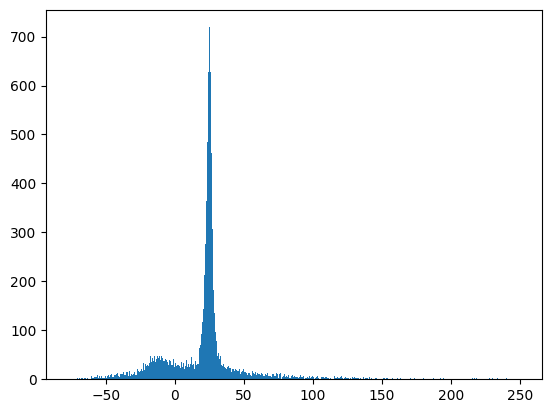

In [342]:
b = (nres1 - m_nrad) / m_nrad * 100
b = np.where(b < 250, b, np.nan)
_ = plt.hist(b.ravel(), bins=500)

The large bias is still present

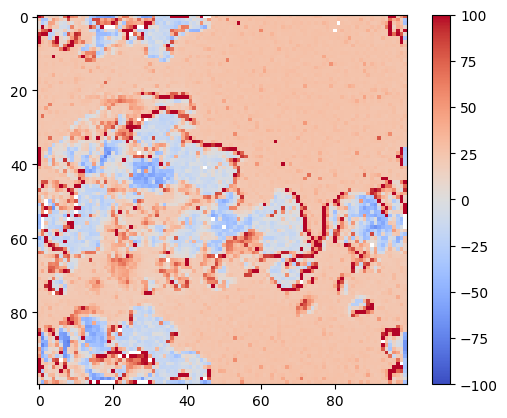

In [343]:
m = np.clip(np.nanmax(b),0, 100)
plt.colorbar(plt.imshow(b, vmin=-m, vmax=m, cmap="coolwarm"))